In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: /home/alex_real/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ruta = '/home/alex_real/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv'

In [4]:
Banco01 = pd.read_csv(ruta)

In [9]:
Banco01

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [11]:
Solo_variables = Banco01.drop(columns =['Time','Class'])

In [5]:
#Organización del conjunto de Datos de Banco01
#si queremos hacerlo acorde a un tiempo, tenemos la columna 'Time'
#las variables van desde V1 a V28
#una que se llama 'Amount' 
#En nuestro caso, 'Class' nos indica si 0 si no hubo fraude o 1 si hubo fraude

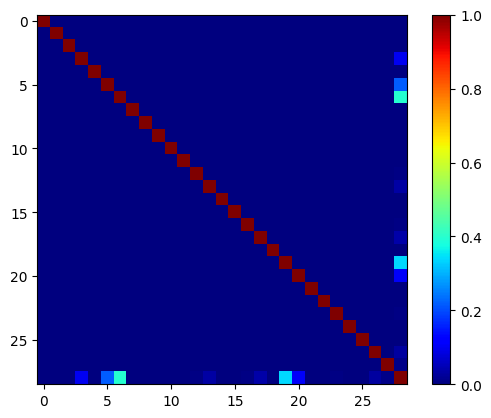

In [16]:
plt.imshow(Solo_variables.corr(), vmin = 0 ,cmap = 'jet')
plt.colorbar()

In [18]:
# Asumiendo que tu columna de respuesta se llama 'Class'
# y el resto son tus variables
correlaciones = Solo_variables.corrwith(Banco01['Class']).abs().sort_values(ascending=False)
print(correlaciones)

V17       0.326481
V14       0.302544
V12       0.260593
V10       0.216883
V16       0.196539
V3        0.192961
V7        0.187257
V11       0.154876
V4        0.133447
V18       0.111485
V1        0.101347
V9        0.097733
V5        0.094974
V2        0.091289
V6        0.043643
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
V24       0.007221
Amount    0.005632
V13       0.004570
V26       0.004455
V15       0.004223
V25       0.003308
V23       0.002685
V22       0.000805
dtype: float64


In [6]:
V1 = np.array(Banco01['V1'])
Fraude = np.array(Banco01['Class'])

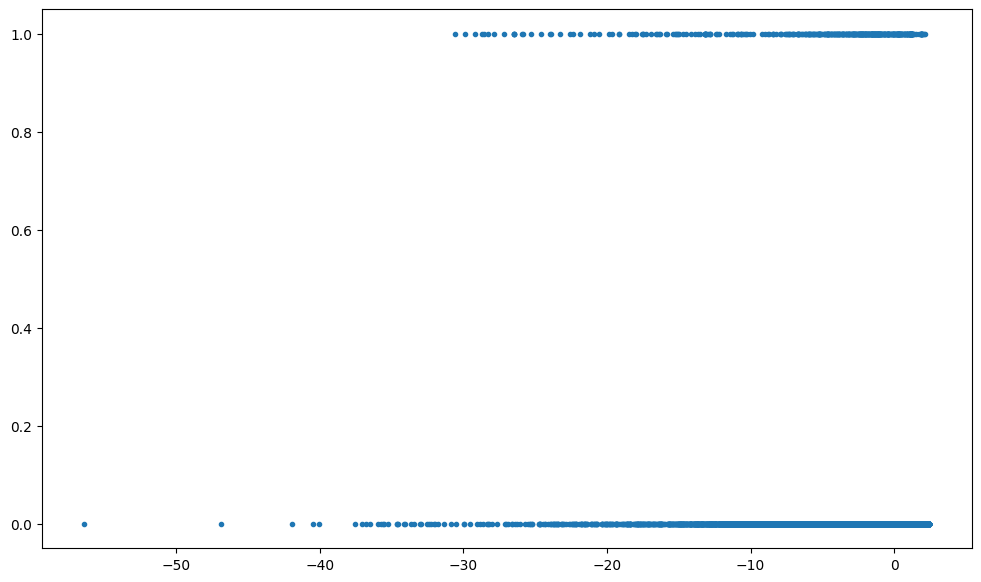

In [7]:
plt.figure(figsize = [12,7])
plt.plot(V1, Fraude, '.')

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

In [20]:
Modelo_total = LogisticRegression()

In [24]:
Fraudes = Banco01['Class']

variables_ent, variables_prueba, fraudes_ent, fraudes_prueba = train_test_split(Solo_variables, Fraudes, test_size=0.3, random_state=42)
 

In [29]:
rfe = RFE(Modelo_total, n_features_to_select=5)

In [30]:
rfe.fit(variables_ent, fraudes_ent)

/home/alex_real/Escritorio/Codigos Jupyter/.envcc/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",5
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [34]:
nombres_ganadores = Solo_variables.columns[rfe.support_]

print("Las variables ganadoras son:")
print(nombres_ganadores)

Las variables ganadoras son:
Index(['V4', 'V14', 'V16', 'V21', 'V22'], dtype='object')


In [37]:
predict = rfe.predict(variables_prueba)

In [39]:
predict.sum()
fraudes_prueba.sum()

np.int64(136)

In [33]:
#Para una variable V1 y Fraudes

# 1. Instanciar y entrenar
modelo_v01 = LogisticRegression()
modelo_v01.fit(V1.reshape((-1, 1)), Fraude)

# 2. Obtener los parámetros
pesos = modelo_v01.coef_        # Esto te da los w para n-variables
ordenada = modelo_v01.intercept_ # Esto te da el b (bias)

#print(f"Pesos (w): {pesos}")
#print(f"Ordenada (b): {ordenada}")



In [34]:
pesos[0]

array([-0.22405195])

In [35]:
def f_logistica_v01(x1):
    f = 1/(1+np.exp(-(pesos[0]*x1+ordenada[0])))
    return f

In [36]:
X1 = np.linspace(np.min(V1), np.max(V1), 100)

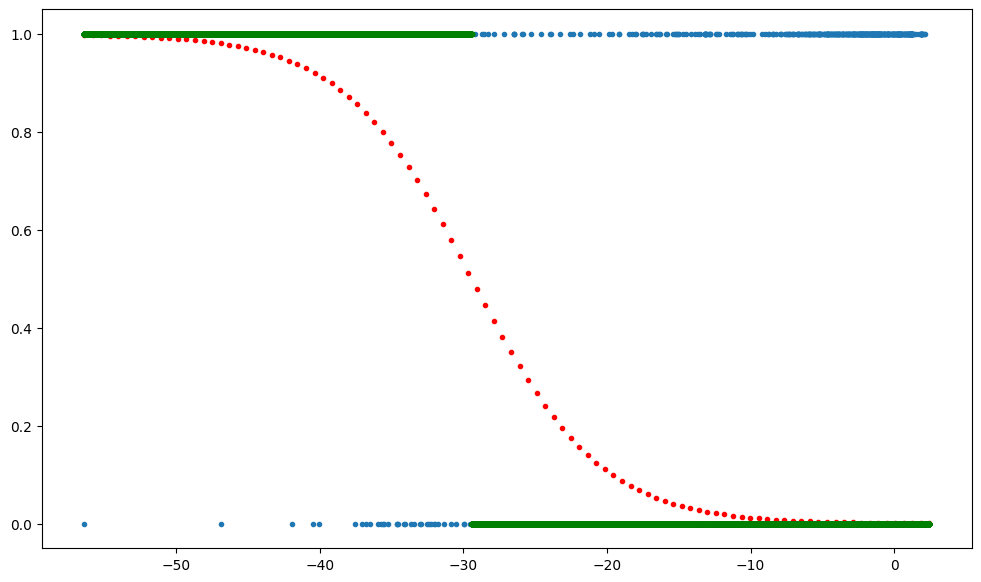

In [50]:
plt.figure(figsize = [12,7])
plt.plot(V1, Fraude, '.')
plt.plot(X1,f_logistica_v01(X1), 'r.')
plt.plot(V01_Negocio, prediccion_clase, 'g.')

In [38]:
## Predicción con una sola variable
## Creamos valores de variable V1 para la cuenta de más de 39000 transacciones.
# 1. Generas tus datos
N = 39777
v01_negocio = np.random.uniform(np.min(V1), np.max(V1), 39777)

# 2. Los guardas en un archivo 'condiciones_iniciales.npy'
np.save('v01_negocio.npy', v01_negocio)

print("Datos guardados. Ya no necesitas correr esta celda de nuevo.")

Datos guardados. Ya no necesitas correr esta celda de nuevo.


In [40]:
V01_Negocio = np.load('v01_negocio.npy')

In [42]:
# OPCIÓN A: Obtener directamente la clase (0 o 1)
prediccion_clase = modelo_v01.predict(V01_Negocio.reshape(-1, 1))
print(f"Clases predichas: {prediccion_clase}")
# Salida esperada: [0 1] (por ejemplo)


# OPCIÓN B: Obtener la probabilidad (incertidumbre)
#prediccion_proba = modelo_v01.predict_proba(V01_Negocio)
#print(f"Probabilidades:\n{prediccion_proba}")

# La salida de predict_proba es una matriz de N x 2:
# [[Prob_Clase_0, Prob_Clase_1],
#  [Prob_Clase_0, Prob_Clase_1]]
#
# Ejemplo:
# [[0.85, 0.15],  -> 85% seguro de que es clase 0
#  [0.05, 0.95]]  -> 95% seguro de que es clase 1

Clases predichas: [1 1 0 ... 0 0 1]


In [45]:
prediccion_clase.sum()

np.int64(18263)

Generando uniforme entre: 1.30e-24 y 7.39
------------------------------
Mínimo obtenido: -7.4726 (Límite: -55.0)
Máximo obtenido: 2.0000 (Límite: 2.0)
------------------------------


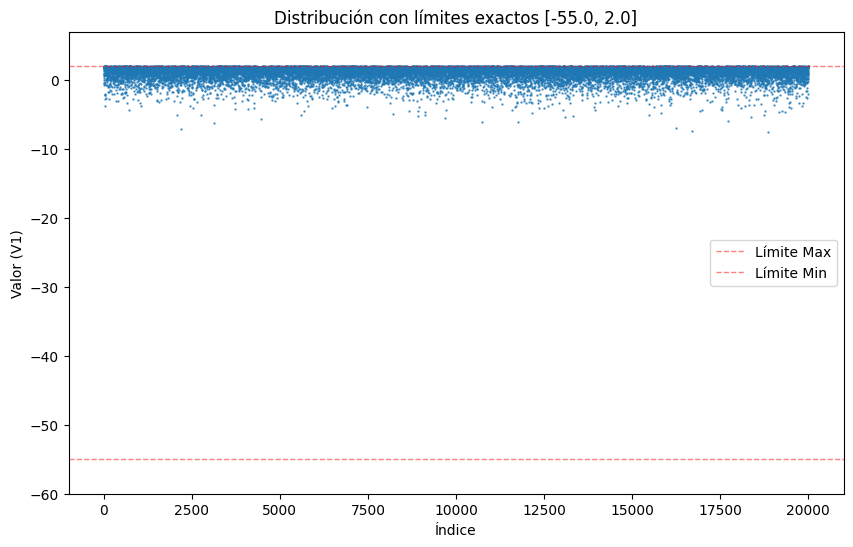

In [55]:


# --- Configuración ---
N = 20000         # Cantidad de puntos (eje X)

# Definimos LOS LÍMITES DUROS EXACTOS que quieres
# (Basado en tu imagen, parece ir de -55 a +2 aproximadamente)
Y_min_duro = -55.0
Y_max_duro = 2.0

# --- Generación de datos ---

# 1. Convertimos los límites lineales a límites exponenciales
# Para que al sacar log(a) nos de Y_min, y log(b) nos de Y_max
a_exp = np.exp(Y_min_duro) # Esto será un número positivo muy pequeño (casi cero)
b_exp = np.exp(Y_max_duro) # Esto será aprox 7.389

print(f"Generando uniforme entre: {a_exp:.2e} y {b_exp:.2f}")

# 2. Generamos una distribución uniforme base en ese rango positivo
datos_uniformes_base = np.random.uniform(low=a_exp, high=b_exp, size=N)

# 3. Aplicamos la transformación logarítmica para obtener la forma deseada
datos_finales = np.log(datos_uniformes_base)

# --- Verificación y Gráfica ---

# Comprobamos que los límites se respetan al 100%
print("-" * 30)
print(f"Mínimo obtenido: {datos_finales.min():.4f} (Límite: {Y_min_duro})")
print(f"Máximo obtenido: {datos_finales.max():.4f} (Límite: {Y_max_duro})")
print("-" * 30)

plt.figure(figsize=(10, 6))
# Usamos markersize pequeño y algo de transparencia (alpha) para replicar el look de tu imagen
plt.plot(datos_finales, '.', markersize=1.5, alpha=0.7, color='#1f77b4')

plt.title(f"Distribución con límites exactos [{Y_min_duro}, {Y_max_duro}]")
plt.ylabel("Valor (V1)")
plt.xlabel("Índice")

# Dibujamos los límites para probar visualmente que no se pasan
plt.axhline(y=Y_max_duro, color='r', linestyle='--', linewidth=1, alpha=0.5, label='Límite Max')
plt.axhline(y=Y_min_duro, color='r', linestyle='--', linewidth=1, alpha=0.5, label='Límite Min')
plt.legend()

# Ajustamos la vista un poco más amplia para ver que no hay nada fuera
plt.ylim(Y_min_duro - 5, Y_max_duro + 5)
plt.show()

In [47]:
V01_Negocio

array([-49.3526925 , -42.29962503,  -8.51586037, ...,  -0.6772374 ,
       -27.8793473 , -35.56299931], shape=(39777,))

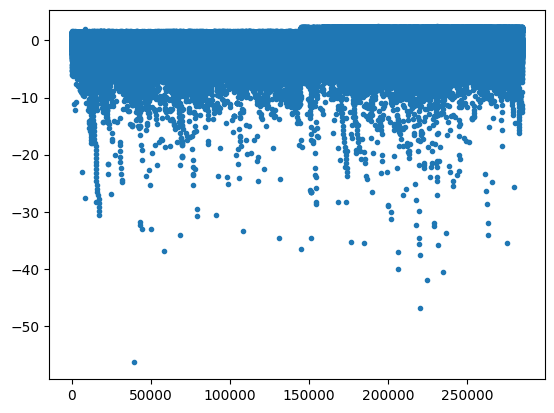

In [53]:
plt.plot(V1, '.')